# 01 · Análisis exploratorio del catálogo

Este notebook analiza el catálogo unificado que genera `backend/scripts/build_catalog.py`
a partir de las fuentes TMDB y MAL:

- **TMDB**: detalles en español de películas y series.
- **MAL**: anime aplanados por `scripts/fetch_mal.py`.

El contrato de `media_type` es `movie | tv | anime` y no se negocia; lo que MAL dice de
sí mismo vive aparte, en `mal_type`.

El parquet de entrada es `../../backend/data/processed/catalog.parquet`, relativo a esta
carpeta. Para regenerarlo:

    cd backend && uv run python -m scripts.build_catalog

**Regla de privacidad.** No se muestra ninguna sinopsis completa ni ninguna tabla larga
de títulos: solo agregados y, como mucho, cinco ejemplos muy cortos por sección.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

RUTA_CATALOGO = "../../backend/data/processed/catalog.parquet"
NOMBRES = {"movie": "Películas", "anime": "Anime", "tv": "Series"}
COLOR_BARRA = "#4c1d95"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (11, 4.5),
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
    "legend.fontsize": 9,
})

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)

df = pd.read_parquet(RUTA_CATALOGO)
print(f"Filas: {len(df)} | Columnas: {len(df.columns)}")

Filas: 9397 | Columnas: 23


## 1. Carga y vista general


Qué miramos: el tamaño del catálogo, cómo se reparte entre las dos fuentes y los tres
tipos de título, y qué tipo de dato tiene cada columna.

Importa fijar esto primero: si una fuente o un tipo dominara el catálogo, cualquier
estadística posterior heredaría ese desequilibrio.

In [2]:
print("Títulos por fuente y por tipo:")
print(df.groupby(["source", "media_type"]).size().rename("titulos").to_frame())

print("\nTipo de dato de cada columna:")
print(df.dtypes.rename("tipo").to_frame())

print("\nReparto cruzado (número de títulos):")
print(pd.crosstab(df["media_type"], df["source"]))

Títulos por fuente y por tipo:
                   titulos
source media_type         
mal    anime          3467
tmdb   movie          4925
       tv             1005

Tipo de dato de cada columna:
                    tipo
id                   str
source               str
media_type           str
mal_type             str
title                str
original_title       str
year               Int64
overview             str
overview_lang        str
genres            object
keywords          object
rating           Float64
vote_count         Int64
popularity       Float64
runtime_total      Int64
runtime_episode    Int64
episodes           Int64
seasons            Int64
status               str
age_rating           str
language             str
poster_url           str
embed_text           str

Reparto cruzado (número de títulos):
source       mal  tmdb
media_type            
anime       3467     0
movie          0  4925
tv             0  1005


El catálogo tiene 9397 títulos y 23 columnas, con un reparto limpio: MAL aporta los 3467 de `media_type=anime`, y TMDB los 4925 de `movie` y los 1005 de `tv`. Ningún tipo aparece en las dos fuentes, de modo que `source` y `media_type` se determinan entre sí y no hace falta filtrar por ambos a la vez. Las columnas de texto son de tipo `object` y dos de ellas (`genres`, `keywords`) guardan listas, mientras que las numéricas usan los tipos de extensión de pandas (`Int64`, `Float64`), que distinguen un nulo de un cero.

## 2. Nulos por columna


Qué miramos: cuántas filas pierde cada columna si se exige que tenga valor.

Distinguimos dos clases muy distintas de hueco. Los nulos **estructurales** son
inevitables y no son un problema: `seasons` solo existe para series, `age_rating` y
`mal_type` solo hay en MAL, y `runtime_total` y `runtime_episode` son
complementarias, así que cada fila solo puede tener valor en una de las dos. Los nulos
**accidentales** sí lo serían, porque significarían que un dato se perdió al construir
el catálogo.

In [3]:
nulos = df.isna().sum()
tabla_nulos = pd.DataFrame({
    "columna": nulos.index,
    "nulos": nulos.values,
    "porcentaje": (nulos / len(df) * 100).round(2).values,
})
tabla_nulos = tabla_nulos[tabla_nulos["nulos"] > 0].reset_index(drop=True)
print("Columnas con algún nulo:")
print(tabla_nulos.to_string(index=False))

completas = [columna for columna in df.columns if df[columna].notna().all()]
print(f"\nColumnas sin ni un nulo ({len(completas)}): {', '.join(completas)}")

print("\nFilas que perdería un filtro que exigiera este campo:")
for columna in ("year", "rating", "runtime_total", "runtime_episode", "episodes",
                "seasons", "age_rating", "mal_type"):
    vacias = int(df[columna].isna().sum())
    print(f"  {columna:<11} {vacias:>5} nulos -> {len(df) - vacias:>5} filas utilizables "
          f"({(len(df) - vacias) / len(df) * 100:.1f} %)")

Columnas con algún nulo:
        columna  nulos  porcentaje
       mal_type   5930       63.11
  runtime_total   3701       39.38
runtime_episode   5705       60.71
       episodes   4948       52.66
        seasons   8392       89.31
     age_rating   5930       63.11
     poster_url      1        0.01

Columnas sin ni un nulo (16): id, source, media_type, title, original_title, year, overview, overview_lang, genres, keywords, rating, vote_count, popularity, status, language, embed_text

Filas que perdería un filtro que exigiera este campo:
  year            0 nulos ->  9397 filas utilizables (100.0 %)
  rating          0 nulos ->  9397 filas utilizables (100.0 %)
  runtime_total  3701 nulos ->  5696 filas utilizables (60.6 %)
  runtime_episode  5705 nulos ->  3692 filas utilizables (39.3 %)
  episodes     4948 nulos ->  4449 filas utilizables (47.3 %)
  seasons      8392 nulos ->  1005 filas utilizables (10.7 %)
  age_rating   5930 nulos ->  3467 filas utilizables (36.9 %)
  mal_type

Solo 7 de las 23 columnas tienen nulos, y las otras 16 están completas. Los nulos grandes son estructurales: `seasons` (89.31 %) solo existe en las 1005 series, `episodes` (52.66 %) falta en las 4925 películas, y `age_rating` y `mal_type` (63.11 % cada uno) solo existen en las 3467 filas de MAL. Las dos columnas de duración también son estructurales, y además complementarias: `runtime_episode` falta en el 60.71 % porque las películas no tienen episodio, y `runtime_total` falta en el 39.38 % porque las series y el anime por episodio no tienen duración total. Los únicos nulos que parecen pérdida real son las 9 filas que se quedan sin duración en las dos columnas (5 series y 4 anime) y 1 `poster_url` (0.01 %). En la práctica `year`, `rating`, `overview`, `title` y `embed_text` están al 100 %, así que filtrar por cualquiera de ellos no descarta ninguna fila.

## 3. Géneros canónicos


Qué miramos: los quince géneros canónicos más frecuentes en cada tipo de título, y
cuántos títulos se quedan sin ninguno.

`genres` es una lista de texto con el vocabulario cerrado de veinte géneros en español
definido en `build_catalog.py`. Todo lo que no tenía equivalente canónico se guardó en
`keywords` en lugar de inventar una traducción, así que un título con `genres` vacía no
está necessariamente sin información temática.

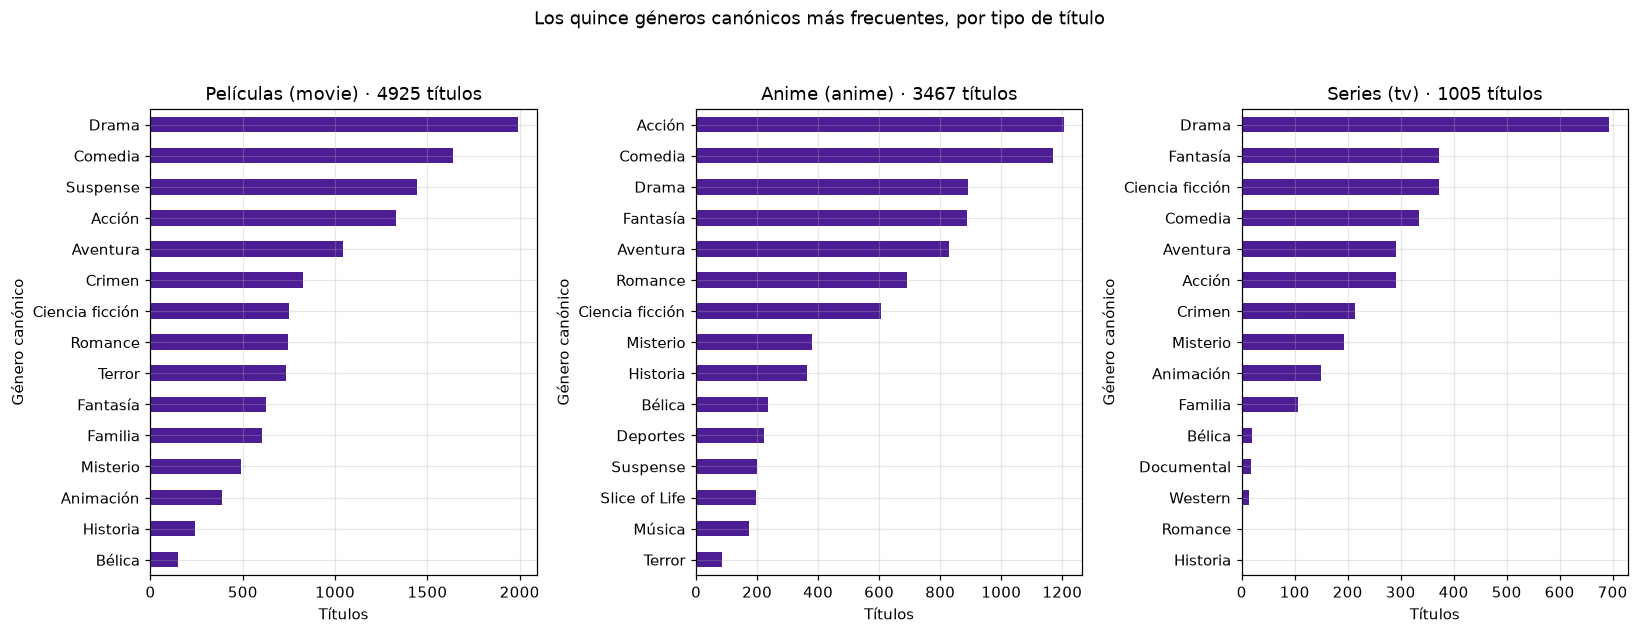

Títulos sin ningún género canónico:
media_type
anime    42
movie     0
tv        8

Total: 50 de 9397 títulos (0.5 %)

Géneros canónicos presentes en el catálogo: 20 de 20


In [4]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 5.5))
for eje, media_type in zip(ejes, ["movie", "anime", "tv"]):
    sub = df[df["media_type"] == media_type]
    conteo = pd.Series([g for lista in sub["genres"] for g in lista]).value_counts().head(15)
    conteo.sort_values().plot.barh(ax=eje, color=COLOR_BARRA, edgecolor="none")
    eje.set_title(f"{NOMBRES[media_type]} ({media_type}) · {len(sub)} títulos")
    eje.set_xlabel("Títulos")
    eje.set_ylabel("Género canónico")
    eje.grid(axis="y", alpha=0.3)
fig.suptitle("Los quince géneros canónicos más frecuentes, por tipo de título", y=1.04)
fig.tight_layout()
plt.show()

sin_genero = df["genres"].map(len) == 0
print("Títulos sin ningún género canónico:")
por_tipo = df.assign(sin_genero=sin_genero).groupby("media_type")["sin_genero"].sum()
print(por_tipo.to_string())
print(f"\nTotal: {int(sin_genero.sum())} de {len(df)} títulos "
      f"({sin_genero.mean() * 100:.1f} %)")

usados = {g for lista in df["genres"] for g in lista}
print(f"\nGéneros canónicos presentes en el catálogo: {len(usados)} de 20")

Los 20 géneros canónicos del vocabulario cerrado están presentes, así que la cobertura es completa. Solo 50 títulos (0.5 %) se quedan sin género canónico: 42 anime y 8 series, y ninguna película. Como lo que no tiene equivalente canónico se guarda en `keywords` en vez de traducirse, para esos 50 casos hay que mirar `keywords` en lugar de asumir que el título no tiene información temática.

## 4. Años


Qué miramos: la distribución del año por tipo de título, su rango y los casos raros.

Un año imposible (futuro, posterior a 2026) delataría un problema al extraer el año de
la fecha original; un año muy antiguo delataría una fecha mal puesta. Hay que separar
las dos cosas antes de decidir si hace falta limpiar.

Año por tipo de título:
            count   min     p25  mediana     p75   max
media_type                                            
anime        3467  1969  2007.0   2015.0  2021.0  2026
movie        4925  1902  2000.0   2010.0  2017.0  2026
tv           1005  1959  2007.0   2015.0  2020.0  2026


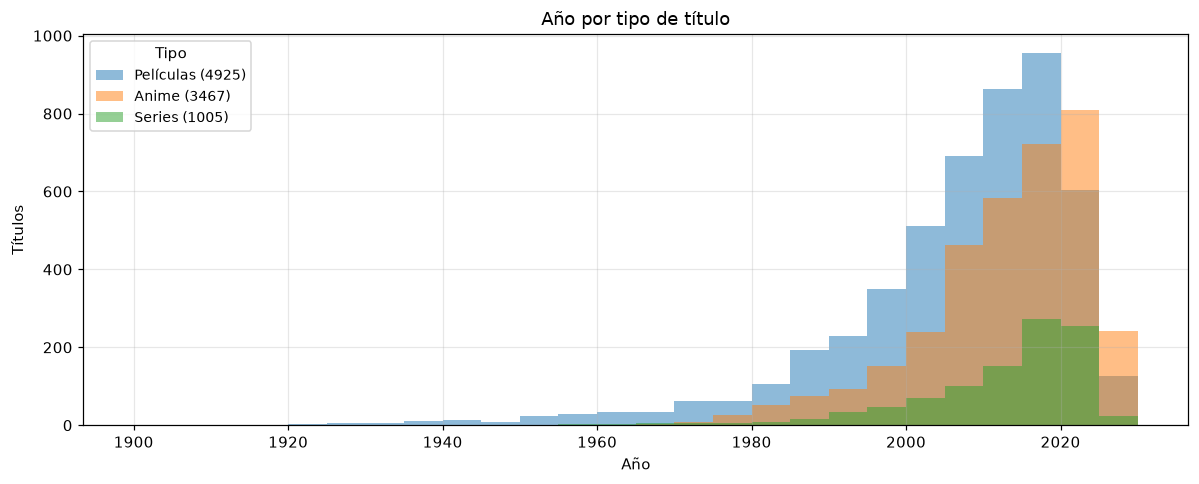


Títulos con año anterior a 1920 o posterior a 2026: 1
Ejemplos (máximo cinco):
            id media_type  year              title
tmdb-movie-775      movie  1902 El viaje a la Luna

Años con menos títulos en el anime:
            id  year                title
mal-anime-3009  1969           Tiger Mask
mal-anime-5760  1969 Dororo to Hyakkimaru
mal-anime-2402  1970        Ashita no Joe
mal-anime-1412  1971            Lupin III
 mal-anime-501  1973             Doraemon


In [5]:
resumen = df.groupby("media_type")["year"].agg(["count", "min", "max"]).round(0)
resumen["p25"] = df.groupby("media_type")["year"].quantile(0.25).round(0)
resumen["mediana"] = df.groupby("media_type")["year"].median().round(0)
resumen["p75"] = df.groupby("media_type")["year"].quantile(0.75).round(0)
print("Año por tipo de título:")
print(resumen[["count", "min", "p25", "mediana", "p75", "max"]].sort_index())

fig, eje = plt.subplots(figsize=(11, 4.5))
for media_type in ["movie", "anime", "tv"]:
    anos = df.loc[df["media_type"] == media_type, "year"].dropna().astype(int)
    eje.hist(anos, bins=range(1900, 2031, 5), alpha=0.5,
             label=f"{NOMBRES[media_type]} ({len(anos)})")
eje.set_title("Año por tipo de título")
eje.set_xlabel("Año")
eje.set_ylabel("Títulos")
eje.legend(title="Tipo")
plt.tight_layout()
plt.show()

raros = df[(df["year"] < 1920) | (df["year"] > 2026)]
print(f"\nTítulos con año anterior a 1920 o posterior a 2026: {len(raros)}")
print("Ejemplos (máximo cinco):")
print(raros[["id", "media_type", "year", "title"]].head(5).to_string(index=False))

print("\nAños con menos títulos en el anime:")
print(df.loc[df["media_type"] == "anime"].nsmallest(5, "year")[["id", "year", "title"]].to_string(index=False))

No hay ni un nulo ni ningún año imposible: el máximo es 2026 en los tres tipos. Solo hay un título fuera del rango 1920-2026, *El viaje a la Luna* (1902), que es una película muda auténtica y no un fallo de extracción, así que no hace falta limpiar años. Los extremos del anime también son reales: *Tiger Mask* y *Dororo to Hyakkimaru* (1969), *Ashita no Joe* (1970), *Doraemon* (1973). Las medianas están muy agrupadas (2010 en películas, 2015 en series y anime), lo que indica que las tres fuentes cubren sobre todo títulos recientes.

## 5. Nota media y votos recibidos


Qué miramos: la nota media y el número de votos, por tipo de título y por fuente.

**Aviso importante: las dos fuentes no usan la misma escala.** La nota viene de
`vote_average` en TMDB y de `mean` en MAL, y los votos de `vote_count` frente a
`num_scoring_users`. Son dos sistemas de votación distintos sobre poblaciones distintas,
así que sus notas **no son comparables entre filas** y sus recuentos de votos están en
órdenes de magnitud diferentes. Cualquier puntuación que mezcle las tres fuentes tendrá
que normalizar antes.

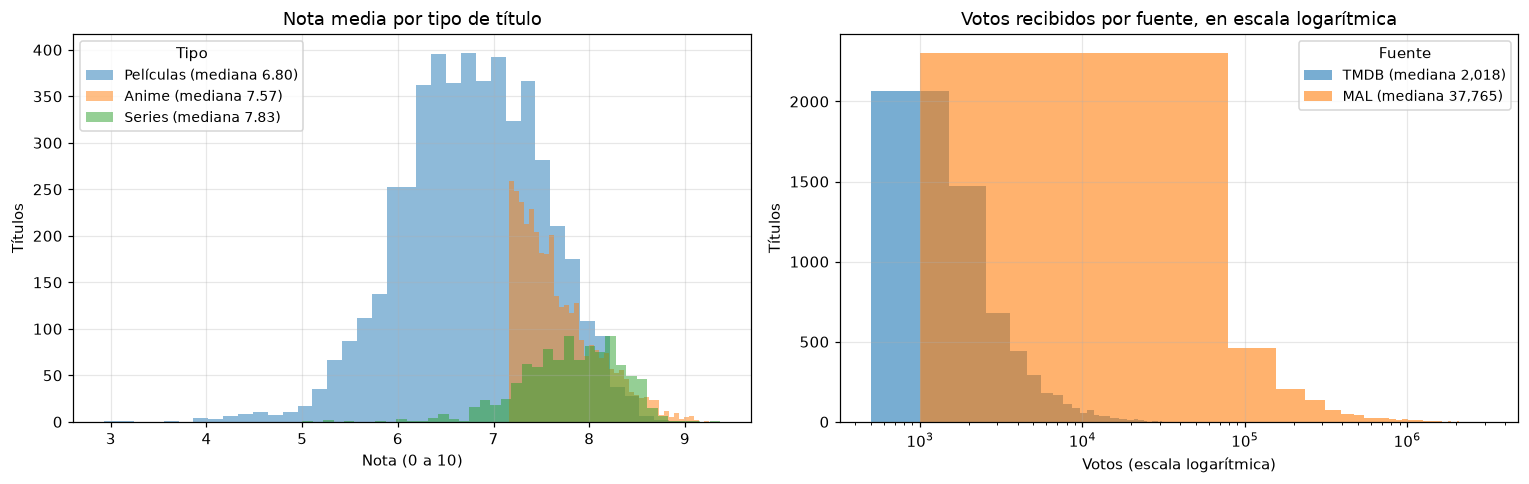

Nota media por fuente:
         count  mean   std   min   10%   25%   50%   75%   90%   max
source                                                              
mal     3467.0  7.67  0.41  7.16  7.23  7.35  7.57   7.9  8.27  9.25
tmdb    5930.0  6.95   0.8  2.93  5.92   6.4  6.97  7.52   8.0  9.37

Votos recibidos por fuente:
         count      mean       std     min      25%      50%       75%       90%        max
source                                                                                     
mal     3467.0  129702.0  265398.0  1006.0  10172.0  37765.0  121693.0  326868.0  3115304.0
tmdb    5930.0    3567.0    4136.0   500.0   1289.0   2018.0    4034.0    7900.0    41330.0


In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.5))
for media_type in ["movie", "anime", "tv"]:
    valores = df.loc[df["media_type"] == media_type, "rating"].dropna()
    ejes[0].hist(valores, bins=40, alpha=0.5,
                 label=f"{NOMBRES[media_type]} (mediana {valores.median():.2f})")
ejes[0].set_title("Nota media por tipo de título")
ejes[0].set_xlabel("Nota (0 a 10)")
ejes[0].set_ylabel("Títulos")
ejes[0].legend(title="Tipo")

for fuente in ["tmdb", "mal"]:
    valores = df.loc[df["source"] == fuente, "vote_count"].dropna()
    ejes[1].hist(valores, bins=40, alpha=0.6,
                 label=f"{fuente.upper()} (mediana {valores.median():,.0f})")
ejes[1].set_xscale("log")
ejes[1].set_title("Votos recibidos por fuente, en escala logarítmica")
ejes[1].set_xlabel("Votos (escala logarítmica)")
ejes[1].set_ylabel("Títulos")
ejes[1].legend(title="Fuente")
fig.tight_layout()
plt.show()

print("Nota media por fuente:")
print(df.groupby("source")["rating"]
      .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(2))
print("\nVotos recibidos por fuente:")
print(df.groupby("source")["vote_count"]
      .describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(0))

Las dos fuentes usan escalas y poblaciones distintas, y se nota mucho. La nota de MAL está comprimida arriba: media 7.67 con desviación 0.41, mínimo 7.16 y ni un solo título por debajo de 7. La de TMDB está mucho más repartida: media 6.95 con desviación 0.80, mínimo 2.93 y percentil 10 en 5.92. El solapamiento es mínimo: el percentil 10 de MAL (7.23) queda por encima de la mediana de TMDB (6.97). Los votos difieren en casi dos órdenes de magnitud, con mediana 37765 en MAL frente a 2018 en TMDB, y media 129702 frente a 3567. Conclusión: `rating` no es comparable entre filas de distintas fuentes, y `vote_count` no sirve como peso común sin normalizar antes.

## 6. Duración: minutos totales frente a minutos por episodio


Qué miramos: cada columna de duración por separado, a qué tipo de título pertenece
cada una, y si el reparto aguanta la invariante de que nunca haya dos con valor.

La duración venía en una columna única, `runtime`, que mezclaba dos unidades: minutos
totales en las películas y minutos por episodio en las series y en el anime. Ahora está
partida en `runtime_total` y `runtime_episode`, así que un umbral del tipo "menos de 30
minutos" ya significa lo mismo en las dos columnas. Lo que queda por comprobar es que
el anime haya ido a la columna correcta, y para eso sirve `mal_type`.

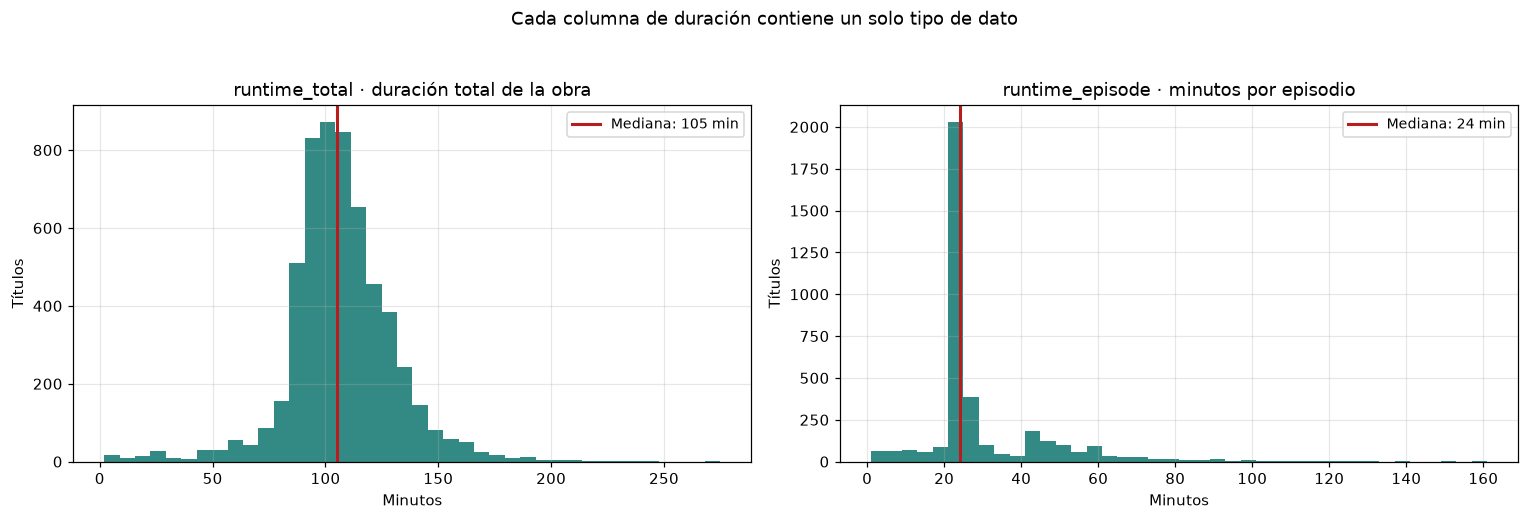

Cada columna por separado:
        columna  con valor  sin valor  mediana  máximo <= 30 min <= 100 min <= 120 min
  runtime_total       5696       3701      105     275     1.3 %     39.3 %     77.2 %
runtime_episode       3692       5705       24     161    76.8 %     99.4 %     99.7 %

Mediana según el tipo de título:
  Películas  runtime_total=   107 | runtime_episode=<NA>
  Anime      runtime_total=    94 | runtime_episode=    24
  Series     runtime_total=<NA> | runtime_episode=    45

Reparto del anime según lo que dice MAL (mal_type):
  movie  n=  772 | va a runtime_total   | con valor=  771 | mediana=   94 min
  tv     n= 1958 | va a runtime_episode | con valor= 1956 | mediana=   24 min
  ova    n=  392 | va a runtime_episode | con valor=  392 | mediana=   25 min
  ona    n=  345 | va a runtime_episode | con valor=  344 | mediana=   20 min

Invariante de las columnas:
  runtime_total con valor:   5696
  runtime_episode con valor: 3692
  ninguna de las dos:         9
  las dos a

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.5))
for eje, (columna, titulo) in zip(
    ejes,
    [
        ("runtime_total", "runtime_total · duración total de la obra"),
        ("runtime_episode", "runtime_episode · minutos por episodio"),
    ],
):
    valores = df[columna].dropna().astype(int)
    eje.hist(valores, bins=40, color="#0f766e", edgecolor="none", alpha=0.85)
    eje.axvline(valores.median(), color="#b91c1c", linewidth=2,
                label=f"Mediana: {valores.median():.0f} min")
    eje.set_title(titulo)
    eje.set_xlabel("Minutos")
    eje.set_ylabel("Títulos")
    eje.legend()
fig.suptitle("Cada columna de duración contiene un solo tipo de dato", y=1.04)
fig.tight_layout()
plt.show()

filas = []
for columna in ("runtime_total", "runtime_episode"):
    valores = df[columna].dropna().astype(int)
    filas.append({
        "columna": columna,
        "con valor": len(valores),
        "sin valor": int(df[columna].isna().sum()),
        "mediana": round(valores.median()),
        "máximo": valores.max(),
        "<= 30 min": f"{(valores <= 30).mean() * 100:.1f} %",
        "<= 100 min": f"{(valores <= 100).mean() * 100:.1f} %",
        "<= 120 min": f"{(valores <= 120).mean() * 100:.1f} %",
    })
print("Cada columna por separado:")
print(pd.DataFrame(filas).to_string(index=False))

print("\nMediana según el tipo de título:")
for media_type in ["movie", "anime", "tv"]:
    sub = df[df["media_type"] == media_type]
    total = sub["runtime_total"].dropna().median()
    episodio = sub["runtime_episode"].dropna().median()
    print(f"  {NOMBRES[media_type]:<10} runtime_total={total:>6.0f} | "
          f"runtime_episode={episodio:>6.0f}")

anime = df[df["media_type"] == "anime"]
print("\nReparto del anime según lo que dice MAL (mal_type):")
for mal_type in ["movie", "tv", "ova", "ona"]:
    sub = anime[anime["mal_type"] == mal_type]
    columna = "runtime_total" if mal_type == "movie" else "runtime_episode"
    valores = sub[columna].dropna()
    print(f"  {mal_type:<6} n={len(sub):>5} | va a {columna:<15} | "
          f"con valor={len(valores):>5} | mediana={valores.median():>5.0f} min")

con_total = df["runtime_total"].notna()
con_episodio = df["runtime_episode"].notna()
print("\nInvariante de las columnas:")
print(f"  runtime_total con valor:   {int(con_total.sum())}")
print(f"  runtime_episode con valor: {int(con_episodio.sum())}")
print(f"  ninguna de las dos:         {int((~con_total & ~con_episodio).sum())}")
print(f"  las dos a la vez:           {int((con_total & con_episodio).sum())}")
print(f"  la columna runtime sigue existiendo: {'runtime' in df.columns}")

Las dos columnas quedan separadas y la invariante se cumple: 5696 filas con `runtime_total`, 3692 con `runtime_episode`, 9 sin ninguna de las dos y **ninguna con las dos**. `runtime_total` tiene mediana 105 minutos y máximo 275, con solo un 1.3 % por debajo de 30; `runtime_episode` tiene mediana 24 y máximo 161, con un 76.8 % por debajo de 30. El reparto por tipo encaja: las películas solo tienen `runtime_total` (mediana 107) y las series solo `runtime_episode` (mediana 45). El anime es el único tipo que aparece en las dos columnas, y lo hace según lo que dice MAL de sí mismo: los 772 títulos con `mal_type=movie` van a `runtime_total` con mediana 94, la misma magnitud que las películas, mientras que `tv` (1956), `ova` (392) y `ona` (344) van a `runtime_episode` con medianas de 24, 25 y 20. Con una sola columna esta comprobación salía rara, porque esas 772 películas de anime convivían con minutos por episodio; ahora cada columna contiene un solo tipo de dato, así que un umbral del tipo "menos de 30 minutos" ya significa lo mismo en las dos.

## 7. Texto: idioma, longitud de la sinopsis y palabras clave


Qué miramos: en qué idioma están las sinopsis de cada fuente, cuánto miden, y cuántas
palabras clave trae cada título.

El idioma importa para la fase de incrustaciones: si el catálogo mezcla español e inglés,
los vectores de un modelo multilingüe se reparten en dos regiones del espacio. También
comprobamos que las sinopsis de MAL limpiaron sus pies de atribución, porque si
sobrevivieran ensuciarían el texto que se va a incrustar.

In [8]:
print("Idioma de las sinopsis, por fuente:")
print(pd.crosstab(df["source"], df["overview_lang"]))

longitud_sinopsis = df["overview"].str.len()
print("\nLongitud de la sinopsis, en caracteres:")
print(longitud_sinopsis.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(0)
      .to_frame("caracteres"))
print(f"\nSinopsis vacías: {int((longitud_sinopsis == 0).sum())}")
print(f"Sinopsis de menos de 50 caracteres: {int((longitud_sinopsis < 50).sum())}")
print(f"Sinopsis de más de 1500 caracteres: {int((longitud_sinopsis > 1500).sum())}")

numero_keywords = df["keywords"].map(len)
print("\nPalabras clave por título:")
print(numero_keywords.describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2)
      .to_frame("palabras clave"))

sin_keywords = df.assign(ninguna=numero_keywords == 0)
print("\nTítulos sin ninguna palabra clave:")
tabla = sin_keywords.groupby("media_type")["ninguna"].agg(["sum", "count"])
tabla["porcentaje"] = (tabla["sum"] / tabla["count"] * 100).round(1)
print(tabla)
print(f"\nTotal: {int(sin_keywords['ninguna'].sum())} de {len(df)} títulos "
      f"({sin_keywords['ninguna'].mean() * 100:.1f} %)")

Idioma de las sinopsis, por fuente:
overview_lang    en    es
source                   
mal            3467     0
tmdb             16  5914

Longitud de la sinopsis, en caracteres:
       caracteres
count      9397.0
mean        525.0
std         301.0
min          21.0
5%          144.0
25%         294.0
50%         461.0
75%         728.0
95%        1076.0
max        3250.0

Sinopsis vacías: 0
Sinopsis de menos de 50 caracteres: 128
Sinopsis de más de 1500 caracteres: 22

Palabras clave por título:
       palabras clave
count         9397.00
mean             9.54
std              8.63
min              0.00
25%              2.00
50%              7.00
75%             15.00
90%             21.00
max             98.00

Títulos sin ninguna palabra clave:
            sum  count  porcentaje
media_type                        
anime       356   3467        10.3
movie        20   4925         0.4
tv           18   1005         1.8

Total: 394 de 9397 títulos (4.2 %)


El catálogo es bilingüe y no por casualidad: las 3467 sinopsis de MAL están en inglés y las 5914 de TMDB en español, con solo 16 títulos de TMDB que ya venían en inglés. Ninguna sinopsis está vacía; la mediana es de 461 caracteres, el percentil 95 de 1076 y el máximo de 3250, con 128 títulos por debajo de 50 caracteres y solo 22 por encima de 1500. Las palabras clave están bastante menos repartidas: mediana 7, media 9.54 y máximo 98, con más de la cuarta parte de los títulos por encima de 15. Faltan por completo en 394 títulos (4.2 %), y el desequilibrio es marcado: 10.3 % del anime frente a 0.4 % de las películas y 1.8 % de las series.

## 8. El texto de incrustación y su coste en tokens


Qué miramos: cuánto mide `embed_text`, el texto que se usará al incrustar, y qué
proporción superaría el límite de 512 tokens.

**Aproximación, no medición.** En este entorno no hay ningún tokenizador instalado, así
que el conteo de tokens es una estimación: se asume que un token equivale a unos cuatro
caracteres, de modo que 512 tokens son aproximadamente 2048 caracteres. La cifra real
dependerá del modelo que se use más adelante. El objetivo aquí es ver si el catálogo
queda cerca del límite o si hay que trocearlo.

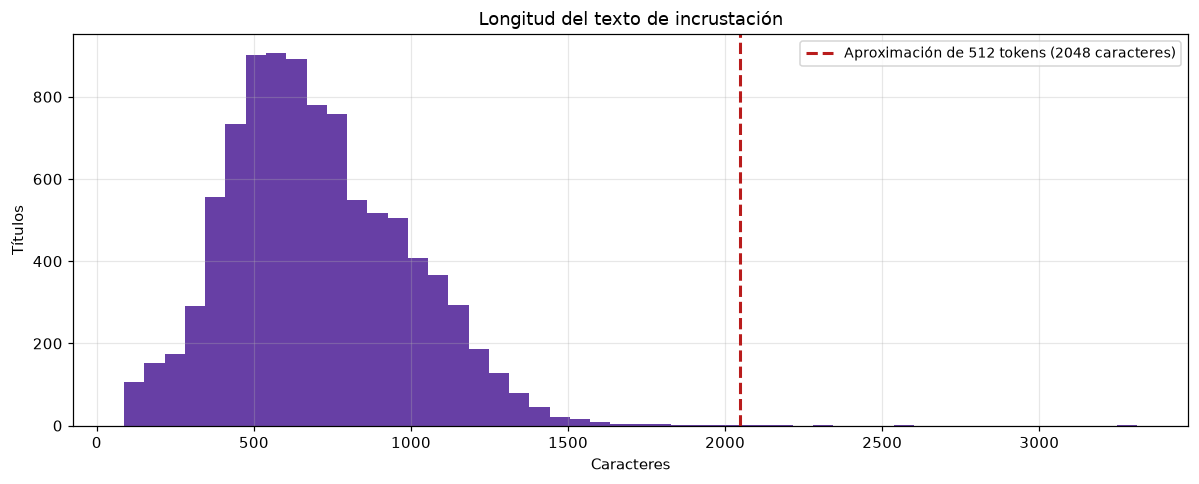

Longitud del texto de incrustación, en caracteres:
       caracteres
count      9397.0
mean        702.0
std         282.0
min          87.0
25%         499.0
50%         666.0
75%         892.0
90%        1091.0
95%        1193.0
99%        1399.0
max        3312.0

Por tipo de título:
            titulos  mediana  maximo  pasan de 512 tokens  porcentaje
media_type                                                           
anime          3467    870.0    2538                    5        0.14
movie          4925    624.0    1315                    0        0.00
tv             1005    495.0    3312                    1        0.10

Qué explica la longitud del texto de incrustación:
  con el número de palabras clave: -0.105
  con la longitud de la sinopsis:    +0.969

Títulos más largos del catálogo (solo longitud, sin mostrar el texto):
             id media_type  longitud
  tmdb-tv-13027         tv      3312
 mal-anime-5751      anime      2538
 mal-anime-3665      anime      2292
mal-

In [9]:
longitud_embedding = df["embed_text"].str.len()
LIMITE_CARACTERES = 512 * 4

fig, eje = plt.subplots(figsize=(11, 4.5))
eje.hist(longitud_embedding, bins=50, color=COLOR_BARRA, edgecolor="none", alpha=0.85)
eje.axvline(LIMITE_CARACTERES, color="#b91c1c", linestyle="--", linewidth=2,
            label=f"Aproximación de 512 tokens ({LIMITE_CARACTERES} caracteres)")
eje.set_title("Longitud del texto de incrustación")
eje.set_xlabel("Caracteres")
eje.set_ylabel("Títulos")
eje.legend()
plt.tight_layout()
plt.show()

print("Longitud del texto de incrustación, en caracteres:")
print(longitud_embedding.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(0)
      .to_frame("caracteres"))

con_exceso = df.assign(longitud=longitud_embedding, exceso=longitud_embedding > LIMITE_CARACTERES)
tabla = con_exceso.groupby("media_type").agg(
    titulos=("longitud", "count"),
    mediana=("longitud", "median"),
    maximo=("longitud", "max"),
    exceso=("exceso", "sum"),
)
tabla["mediana"] = tabla["mediana"].round(0)
tabla["maximo"] = tabla["maximo"].round(0)
tabla["porcentaje"] = (tabla["exceso"] / tabla["titulos"] * 100).round(2)
tabla = tabla.rename(columns={"exceso": "pasan de 512 tokens"})
print("\nPor tipo de título:")
print(tabla[["titulos", "mediana", "maximo", "pasan de 512 tokens", "porcentaje"]].sort_index())

print("\nQué explica la longitud del texto de incrustación:")
print(f"  con el número de palabras clave: {longitud_embedding.corr(numero_keywords):+.3f}")
print(f"  con la longitud de la sinopsis:    {longitud_embedding.corr(longitud_sinopsis):+.3f}")

print("\nTítulos más largos del catálogo (solo longitud, sin mostrar el texto):")
largos = con_exceso.nlargest(5, "longitud")
print(largos[["id", "media_type", "longitud"]].reset_index(drop=True).to_string(index=False))

El texto de incrustación es manejable: mediana de 666 caracteres, percentil 99 de 1399 y máximo 3312. Aplicando la aproximación de cuatro caracteres por token, solo 6 títulos de 9397 (0.06 %) superarían el límite de 512 tokens: 5 de anime (0.14 %) y 1 serie (0.10 %), y ninguna película. Al ser una estimación y no una medición con tokenizador, la cifra real habrá que recalcularla cuando se elija el modelo, pero el margen es enorme. Lo relevante es qué manda en la longitud: la correlación con la sinopsis es +0.969 y con el número de palabras clave solo -0.105, así que en la práctica `embed_text` es la sinopsis más un poco de contexto. Bajar el tope de palabras clave apenas reduciría el coste, aunque el corte a 15 afecte a más de la cuarta parte de los títulos.

## 9. Conclusiones

### Siete hallazgos

1. **Las notas no son comparables entre fuentes.** MAL tiene media 7.67 y desviación 0.41, con un mínimo de 7.16; TMDB tiene media 6.95 y desviación 0.80, con un mínimo de 2.93. El percentil 10 de MAL (7.23) está por encima de la mediana de TMDB (6.97).
2. **Los votos están en órdenes de magnitud distintos.** La mediana es 37765 en MAL y 2018 en TMDB, casi 19 veces menos.
3. **La duración está partida por unidad.** `runtime_total` (5696 filas, mediana 105 minutos) lleva las 4925 películas y el anime que MAL clasifica como `movie`; `runtime_episode` (3692 filas, mediana 24) lleva las 1005 series y el resto del anime. Ninguna fila tiene las dos, y solo 9 se quedan sin duración.
4. **El catálogo es bilingüe.** 5914 sinopsis en español frente a 3483 en inglés, concentradas por fuente.
5. **La sinopsis domina el texto de incrustación.** La correlación con la longitud de la sinopsis es +0.969, y con el número de palabras clave solo -0.105.
6. **El troceado casi no hace falta.** Con la aproximación de caracteres por token, solo el 0.06 % de los títulos pasa de 512 tokens, y ninguna película.
7. **Los datos están saneados.** Cero nulos en `year`, `rating`, `overview`, `title` y `embed_text`; cero años imposibles; un solo `poster_url` vacío. Los nulos voluminosos (`seasons`, `episodes`, `age_rating`, `mal_type` y las dos columnas de duración) son estructurales, no pérdidas.

### Qué implica para las siguientes fases

- **Modelo de incrustación:** hace falta uno multilingüe, porque el texto mezcla español e inglés. Con 512 tokens basta sin trocear, pero hay que repetir la medición con el tokenizador real antes de fijarlo.
- **Puntuación de recomendación:** normalizar `rating` dentro de cada fuente antes de mezclar, y usar `vote_count` solo tras normalizarlo. Ordenar las tres fuentes con una puntuación única sin ese paso favorece al anime de MAL.
- **Filtros por duración:** `runtime_total` responde a cuánto dura la obra y `runtime_episode` a cuánto dura un episodio, y ya no se mezclan. Ahora el filtro de "menos de 30 minutos" descarta un 1.3 % de lo que tiene duración total y un 76.8 % de lo que va por episodio, y las dos cifras significan lo mismo. Lo que no se puede es aplicar un único umbral a las 9397 filas sin decidir antes cuál de las dos columnas se está usando.
- **Filtros por edad:** `age_rating` solo existe en las 3467 filas de MAL, un 36.9 % del catálogo. Ningún filtro por edad puede ser global sin tratar antes a TMDB.
- **Palabras clave:** no sirven para el anime, donde faltan en el 10.3 % de los títulos. La sinopsis es el único texto fiable ahí.

### Límites de este análisis

- El conteo de tokens es una **aproximación** de cuatro caracteres por token, no una medición: no hay tokenizador instalado en el entorno.
- Comparar las distribuciones de `rating` no significa comparar la misma escala. Son dos sistemas de votación distintos, con poblaciones distintas.
- La ambigüedad de la duración está resuelta con las dos columnas, pero quedan 9 filas sin ella (5 series y 4 anime). Es un 0.10 % y no altera ninguna conclusión.
- Esto es una fotografía de un único volcado: no se ha comprobado la coherencia entre `title` y `original_title`, ni si hay títulos repetidos entre TMDB y MAL tras el descarte de duplicados.
- Las conclusiones son descriptivas. No dicen nada todavía sobre si el catálogo representa bien a los títulos que la gente quiere ver, que es lo que medirá la evaluación posterior.